# Flujo de Trabajo de Imputación para Pampaneira (Refactorizado)

Este cuaderno ejecuta el pipeline refactorizado para imputar valores faltantes en el conjunto de datos de Pampaneira.

## 1. Configuración e Importaciones

Aseguramos que la raíz del proyecto esté en el path de Python. Ajusta la profundidad del path ('../') según sea necesario dependiendo de dónde se encuentre este cuaderno en relación con la raíz del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import sys
from sklearn.preprocessing import StandardScaler # Mantener para uso directo/verificación potencial
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import SmoothL1Loss

# Asegurar que la raíz del proyecto esté en el Python path
# Ajusta la profundidad del path ('../') según sea necesario
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

Importamos los módulos refactorizados del proyecto:

In [2]:
# Importar módulos refactorizados
from pampaneira_imputation import config
from pampaneira_imputation import data_loader as dl
from pampaneira_imputation import data_preprocessor as dp
from pampaneira_imputation import imputation_methods as im
from pampaneira_imputation import evaluation as ev
from pampaneira_imputation import utils


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



Importamos SAITS por separado (asumiendo que pypots está instalado):

In [3]:
# Importar SAITS por separado (asumiendo que pypots está instalado)
try:
    from pypots.imputation import SAITS
except ImportError:
    print("Advertencia: No se encontró la librería pypots. La imputación con SAITS no estará disponible.")
    SAITS = None # Definir como None si no está disponible

Configuramos pandas y la visualización:

In [4]:
# Configurar pandas y visualización
pd.options.mode.chained_assignment = None
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
plt.rcParams["figure.figsize"] = [12, 4]
warnings.filterwarnings("ignore") # Usar con precaución

## 2. Carga de Datos

Cargamos los datos de la intersección (filtrados para PAM_2):

In [5]:
# Cargar datos de intersección (filtrados para PAM_2)
try:
    df_int_raw = dl.load_intersection_data(
        filepath=config.INTERSECTION_FILE,
        target_truck_pos=config.TARGET_TRUCK_POS
    )
    print(f"Forma de los datos de intersección cargados: {df_int_raw.shape}")
    print(f"Rango de fechas: {df_int_raw[config.DATE_COL].min()} a {df_int_raw[config.DATE_COL].max()}")
    # display(df_int_raw.head()) # Opcional: mostrar encabezado
except Exception as e:
    print(f"Error al cargar los datos de intersección: {e}")
    # Detener ejecución o manejar el error apropiadamente
    raise

Forma de los datos de intersección cargados: (1335, 115)
Rango de fechas: 2023-01-17 17:00:00+00:00 a 2023-06-27 00:00:00+00:00


## 3. Preprocesamiento de Datos

### 3.1 Rellenar Marcas de Tiempo Faltantes (Dentro de Periodos Definidos)

Creamos el rango de fechas completo que cubre ambos periodos conocidos de datos del camión:

In [6]:
# Crear el rango de fechas completo que cubre ambos periodos conocidos
full_range = pd.date_range(start=config.PERIOD_1_START, end=config.PERIOD_1_END, freq='h', tz=config.TIMEZONE).union(
    pd.date_range(start=config.PERIOD_2_START, end=config.PERIOD_2_END, freq='h', tz=config.TIMEZONE)
)

Reindexamos los datos cargados a este rango combinado:

In [7]:
# Reindexar los datos cargados a este rango combinado
df_int_reindexed = df_int_raw.set_index(config.DATE_COL).reindex(full_range).reset_index()
df_int_reindexed = df_int_reindexed.rename(columns={'index': config.DATE_COL})
print(f"Forma después de reindexar a periodos combinados: {df_int_reindexed.shape}")
# display(df_int_reindexed.head()) # Opcional

Forma después de reindexar a periodos combinados: (1831, 115)


Verificamos los NaNs introducidos por la reindexación:

In [8]:
# Verificar los NaNs introducidos
print(f"NaNs introducidos por reindexación: {df_int_reindexed.isnull().sum().sum()}")

NaNs introducidos por reindexación: 58968


### 3.2 Dividir en Periodos

Establecemos la columna de fecha como índice y dividimos el DataFrame en los dos periodos definidos en la configuración.

In [9]:
# Dividir en Periodos
df_int_reindexed.set_index(config.DATE_COL, inplace=True)
periodo_1_raw, periodo_2_raw = dp.split_by_period(df_int_reindexed)

print(f"Forma del Periodo 1: {periodo_1_raw.shape}")
print(f"Forma del Periodo 2: {periodo_2_raw.shape}")

Forma del Periodo 1: (1339, 114)
Forma del Periodo 2: (492, 114)


### 3.3 Añadir Relleno (Padding) al Periodo 1

Añadimos relleno con valores NaN al inicio y final del DataFrame del Periodo 1 para asegurar que cubra completamente las fechas definidas para el entrenamiento, validación y test, incluso si los datos originales no comenzaban o terminaban exactamente en esas fechas.

In [10]:
# Añadir Relleno (Padding) al Periodo 1
periodo_1_padded = dp.add_period1_padding(periodo_1_raw)
print(f"Forma del Periodo 1 después del padding: {periodo_1_padded.shape}")
print(f"Rango de fechas con padding: {periodo_1_padded.index.min()} a {periodo_1_padded.index.max()}")
# display(periodo_1_padded.head()) # Opcional
# display(periodo_1_padded.tail()) # Opcional

Forma del Periodo 1 después del padding: (1368, 114)
Rango de fechas con padding: 2023-01-17 00:00:00+00:00 a 2023-03-14 23:00:00+00:00


### 3.3 Añadir Relleno (Padding) al Periodo 2

In [11]:
# Añadir Relleno (Padding) al Periodo 2
periodo_2_padded = dp.add_period2_padding(periodo_2_raw)
print(f"Forma del Periodo 2 después del padding: {periodo_2_padded.shape}")
print(f"Rango de fechas con padding: {periodo_2_padded.index.min()} a {periodo_2_padded.index.max()}")
# display(periodo_2_padded.head()) # Opcional
# display(periodo_2_padded.tail()) # Opcional

Forma del Periodo 2 después del padding: (528, 114)
Rango de fechas con padding: 2023-06-06 00:00:00+00:00 a 2023-06-27 23:00:00+00:00


### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

In [12]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data = dp.preprocess_for_imputation(
        periodo_1_padded,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Introduciendo 10.0% de datos faltantes con patrón 'point'...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_index: longitud 864
- val_index: longitud 216
- test_index: longitud 288
- train_X_ori: forma (841, 24, 114)
- val_X_ori: forma (193, 24, 114)
- test_X_ori: forma (265, 24, 114)
- train_X: forma (841, 24, 114)
- val_X: forma (193, 24, 114)
- test_X: forma (265, 24, 114)
- train_missing_mask: forma (841, 24, 114)
- val_missing_mask: forma (193, 24, 114)
- test_missing_mask: forma (265, 24, 114)
- train_indicating_mask: forma (841, 24, 114)
- val_indicating_mask: forma (193, 24, 114)
- test_indicating_mask: forma (265, 24, 114)
- n_train_samples: 841
- n_val_samples: 193
- n_test_samples: 265


Preparamos los conjuntos de datos para PyPOTS (u otras bibliotecas) si es necesario:

In [13]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training = {"X": processed_data['train_X']}
dataset_for_validating = {"X": processed_data['val_X'], "X_ori": processed_data['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing = {
    "X": processed_data['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "indicating_mask": processed_data['test_indicating_mask'] # Máscara de los NaNs introducidos
    }

### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 2

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

In [14]:
periodo_2_padded

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-06-06 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-06 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-06 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-06 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-06 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-27 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-27 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-27 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-27 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fechas de división del periodo 2 (22 días)

- 80% Fase de entrenamiento: 18 días
    - **Training:** 80% de 18: **14 días** (2023-06-06 al 2023-06-19)
    - **Validación:** 20% de 18: **4 días** (2023-06-20 al 2023-06-23)
- 20% **Testing**: **4 días** (2023-06-24 al 2023-06-27)

In [15]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data2 = dp.preprocess_for_imputation(
        periodo_2_padded,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN,
        train_starn=config.TRAIN_2_START_DATE,
        train_end=config.TRAIN_2_END_DATE,
        val_start=config.VAL_2_START_DATE,
        val_end=config.VAL_2_END_DATE,
        test_start=config.TEST_2_START_DATE,
        test_end=config.TEST_2_END_DATE,
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Introduciendo 10.0% de datos faltantes con patrón 'point'...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_index: longitud 864
- val_index: longitud 216
- test_index: longitud 288
- train_X_ori: forma (841, 24, 114)
- val_X_ori: forma (193, 24, 114)
- test_X_ori: forma (265, 24, 114)
- train_X: forma (841, 24, 114)
- val_X: forma (193, 24, 114)
- test_X: forma (265, 24, 114)
- train_missing_mask: forma (841, 24, 114)
- val_missing_mask: forma (193, 24, 114)
- test_missing_mask: forma (265, 24, 114)
- train_indicating_mask: forma (841, 24, 114)
- val_indicating_mask: forma (193, 24, 114)
- test_indicating_mask: forma (265, 24, 114)
- n_train_samples: 841
- n_val_samples: 193
- n_test_samples: 265


In [16]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training2 = {"X": processed_data2['train_X']}
dataset_for_validating2 = {"X": processed_data2['val_X'], "X_ori": processed_data2['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing2 = {
    "X": processed_data2['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data2['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "indicating_mask": processed_data2['test_indicating_mask'] # Máscara de los NaNs introducidos
}

## 4. Métodos de Imputación Base (Baseline) para Periodo 1

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing['X']`). Almacenamos los resultados en un diccionario.

In [17]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing = dataset_for_testing['X']
imputed_results = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 4.1 Imputación por Mediana

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [18]:
imputed_results['median'] = im.impute_median_sample_wise(X_test_missing)
print(f"Forma imputación mediana: {imputed_results['median'].shape}, NaNs: {np.isnan(imputed_results['median']).sum()}")

Forma imputación mediana: (265, 24, 114), NaNs: 0


### 4.2 Imputación por Media

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [19]:
imputed_results['mean'] = im.impute_mean_sample_wise(X_test_missing)
print(f"Forma imputación media: {imputed_results['mean'].shape}, NaNs: {np.isnan(imputed_results['mean']).sum()}")

Forma imputación media: (265, 24, 114), NaNs: 0


### 4.3 Interpolación Lineal

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [20]:
# ### 4.3 Interpolación Lineal
imputed_results['linear'] = im.impute_linear(X_test_missing)
print(f"Forma imputación lineal: {imputed_results['linear'].shape}, NaNs: {np.isnan(imputed_results['linear']).sum()}")

Forma imputación lineal: (265, 24, 114), NaNs: 0


### 4.4 Relleno Forward/Backward (ffill/bfill)

Aplicamos dos estrategias de relleno local:
1.  `ffill_bfill`: Primero rellenamos hacia adelante (usando el último valor válido conocido) y luego hacia atrás (usando el primer valor válido conocido) para rellenar los huecos restantes.
2.  `bfill_ffill`: Primero rellenamos hacia atrás y luego hacia adelante.

Nota: Estos métodos pueden requerir eliminar columnas como `WS`, `WD` si causan problemas o no son necesarias. La función de imputación en sí no elimina columnas, pero la evaluación podría necesitar alineación. Asumiremos por ahora que imputamos todas las características. La evaluación maneja la posible eliminación de columnas. Alternativamente, modificamos los datos de entrada antes de pasarlos a la imputación:

In [21]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing_no_ws_wd = X_test_missing.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing_no_ws_wd = np.delete(X_test_missing, cols_to_drop_indices, axis=2)
else:
    X_test_missing_no_ws_wd = X_test_missing # No hay columnas que eliminar


fb_imputed, bf_imputed = im.impute_forward_backward(X_test_missing_no_ws_wd)
imputed_results['ffill_bfill'] = fb_imputed
imputed_results['bfill_ffill'] = bf_imputed
print(f"Forma imputación Ffill-Bfill: {imputed_results['ffill_bfill'].shape}, NaNs: {np.isnan(imputed_results['ffill_bfill']).sum()}")
print(f"Forma imputación Bfill-Ffill: {imputed_results['bfill_ffill'].shape}, NaNs: {np.isnan(imputed_results['bfill_ffill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
Forma imputación Ffill-Bfill: (265, 24, 112), NaNs: 0
Forma imputación Bfill-Ffill: (265, 24, 112), NaNs: 0


## 5. Imputación con SAITS (Requiere PyPOTS)

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [22]:
# ## 5. Imputación con SAITS (Requiere PyPOTS)

if SAITS is not None:
    print("\nConfigurando y ejecutando imputación con SAITS...")
    # Configurar modelo SAITS
    saits_config = config.SAITS_PARAMS.copy()
    saits_config['n_features'] = processed_data['n_features'] # Establecer dinámicamente

    saits_model = SAITS(**saits_config)

    # Configurar optimizador, planificador y función de pérdida
    optimizer = Adam(saits_model.model.parameters(), **config.SAITS_OPTIMIZER_PARAMS)
    scheduler = ReduceLROnPlateau(optimizer, **config.SAITS_SCHEDULER_PARAMS)
    loss_func = SmoothL1Loss(**config.SAITS_LOSS_PARAMS)

    # Entrenar el modelo
    # Nota: Podrías querer ajustar epochs/patience para ejecuciones más rápidas
    print("Entrenando modelo SAITS...")
    saits_model.fit(
        train_set=dataset_for_training,
        val_set=dataset_for_validating, # Pasar conjunto de validación para early stopping
        )
    print("Entrenamiento de SAITS completo.")

    # Predecir (imputar) en el conjunto de test
    print("Imputando con SAITS en el conjunto de test...")
    saits_prediction = saits_model.predict(dataset_for_testing)
    imputed_results['saits'] = saits_prediction["imputation"]
    print(f"Forma imputación SAITS: {imputed_results['saits'].shape}, NaNs: {np.isnan(imputed_results['saits']).sum()}")

else:
    print("\nSaltando imputación con SAITS ya que pypots no está instalado.")

2025-04-08 11:50:05 [INFO]: No given device, using default device: cpu



Configurando y ejecutando imputación con SAITS...


2025-04-08 11:50:05 [INFO]: Model files will be saved to ../results/imputation/saits/20250408_T115005
2025-04-08 11:50:05 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250408_T115005/tensorboard
2025-04-08 11:50:05 [INFO]: Using customized MAE as the training loss function.
2025-04-08 11:50:05 [INFO]: Using customized MSE as the validation metric function.
2025-04-08 11:50:05 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800


Entrenando modelo SAITS...


2025-04-08 11:50:07 [INFO]: Epoch 001 - training loss (MAE): 1.1871, validation MSE: 1.0821
2025-04-08 11:50:08 [INFO]: Epoch 002 - training loss (MAE): 0.9058, validation MSE: 1.0266
2025-04-08 11:50:12 [INFO]: Epoch 003 - training loss (MAE): 0.8524, validation MSE: 0.9877
2025-04-08 11:50:14 [INFO]: Epoch 004 - training loss (MAE): 0.8093, validation MSE: 0.9438
2025-04-08 11:50:16 [INFO]: Epoch 005 - training loss (MAE): 0.7693, validation MSE: 0.8833
2025-04-08 11:50:19 [INFO]: Epoch 006 - training loss (MAE): 0.7413, validation MSE: 0.8406
2025-04-08 11:50:21 [INFO]: Epoch 007 - training loss (MAE): 0.7073, validation MSE: 0.7918
2025-04-08 11:50:23 [INFO]: Epoch 008 - training loss (MAE): 0.6891, validation MSE: 0.7573
2025-04-08 11:50:25 [INFO]: Epoch 009 - training loss (MAE): 0.6662, validation MSE: 0.7317
2025-04-08 11:50:27 [INFO]: Epoch 010 - training loss (MAE): 0.6498, validation MSE: 0.7073
2025-04-08 11:50:30 [INFO]: Epoch 011 - training loss (MAE): 0.6351, validation 

Entrenamiento de SAITS completo.
Imputando con SAITS en el conjunto de test...
Forma imputación SAITS: (265, 24, 114), NaNs: 0


## 4. Periodo 2: Métodos de Imputación Base (Baseline)

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing2['X']`). Almacenamos los resultados en un diccionario.

In [23]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing2 = dataset_for_testing2['X']
imputed_results2 = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 4.1 Imputación por Mediana en Periodo 2

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [24]:
imputed_results2['median'] = im.impute_median_sample_wise(X_test_missing2)
print(f"Forma imputación mediana: {imputed_results2['median'].shape}, NaNs: {np.isnan(imputed_results2['median']).sum()}")

Forma imputación mediana: (73, 24, 114), NaNs: 0


### 4.2 Imputación por Media en Periodo 2

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [25]:
imputed_results2['mean'] = im.impute_mean_sample_wise(X_test_missing2)
print(f"Forma imputación media: {imputed_results2['mean'].shape}, NaNs: {np.isnan(imputed_results2['mean']).sum()}")

Forma imputación media: (73, 24, 114), NaNs: 0


### 4.3 Interpolación Lineal en Periodo 2

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [26]:
# ### 4.3 Interpolación Lineal
imputed_results2['linear'] = im.impute_linear(X_test_missing2)
print(f"Forma imputación lineal: {imputed_results2['linear'].shape}, NaNs: {np.isnan(imputed_results2['linear']).sum()}")

Forma imputación lineal: (73, 24, 114), NaNs: 0


### 4.4 Relleno Forward/Backward (ffill/bfill) en Periodo 2


In [27]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing2_no_ws_wd = X_test_missing2.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing2_no_ws_wd = np.delete(X_test_missing2, cols_to_drop_indices, axis=2)
else:
    X_test_missing2_no_ws_wd = X_test_missing2 # No hay columnas que eliminar


fb_imputed, bf_imputed = im.impute_forward_backward(X_test_missing2_no_ws_wd)
imputed_results2['ffill_bfill'] = fb_imputed
imputed_results2['bfill_ffill'] = bf_imputed
print(f"Forma imputación Ffill-Bfill: {imputed_results2['ffill_bfill'].shape}, NaNs: {np.isnan(imputed_results2['ffill_bfill']).sum()}")
print(f"Forma imputación Bfill-Ffill: {imputed_results2['bfill_ffill'].shape}, NaNs: {np.isnan(imputed_results2['bfill_ffill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
Forma imputación Ffill-Bfill: (73, 24, 112), NaNs: 0
Forma imputación Bfill-Ffill: (73, 24, 112), NaNs: 0


In [28]:
print(dataset_for_training2['X'].shape)
print(dataset_for_validating2['X'].shape)
print(dataset_for_testing['X'].shape)

(313, 24, 114)
(73, 24, 114)
(265, 24, 114)


## 5. Periodo 2: Imputación con SAITS

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [29]:
# ## 5. Imputación con SAITS (Requiere PyPOTS)

if SAITS is not None:
    print("\nConfigurando y ejecutando imputación con SAITS...")
    # Configurar modelo SAITS
    saits_config = config.SAITS_PARAMS.copy()
    saits_config['n_features'] = processed_data2['n_features'] # Establecer dinámicamente

    saits_model = SAITS(**saits_config)

    # Configurar optimizador, planificador y función de pérdida
    optimizer = Adam(saits_model.model.parameters(), **config.SAITS_OPTIMIZER_PARAMS)
    scheduler = ReduceLROnPlateau(optimizer, **config.SAITS_SCHEDULER_PARAMS)
    loss_func = SmoothL1Loss(**config.SAITS_LOSS_PARAMS)

    # Entrenar el modelo
    # Nota: Podrías querer ajustar epochs/patience para ejecuciones más rápidas
    print("Entrenando modelo SAITS...")
    saits_model.fit(
        train_set=dataset_for_training2,
        val_set=dataset_for_validating2, # Pasar conjunto de validación para early stopping
        )
    print("Entrenamiento de SAITS completo.")

    # Predecir (imputar) en el conjunto de test
    print("Imputando con SAITS en el conjunto de test...")
    saits_prediction = saits_model.predict(dataset_for_testing2)
    imputed_results2['saits'] = saits_prediction["imputation"]
    print(f"Forma imputación SAITS: {imputed_results2['saits'].shape}, NaNs: {np.isnan(imputed_results2['saits']).sum()}")

else:
    print("\nSaltando imputación con SAITS ya que pypots no está instalado.")

2025-04-08 11:51:51 [INFO]: No given device, using default device: cpu
2025-04-08 11:51:51 [INFO]: Model files will be saved to ../results/imputation/saits/20250408_T115151
2025-04-08 11:51:51 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250408_T115151/tensorboard
2025-04-08 11:51:51 [INFO]: Using customized MAE as the training loss function.
2025-04-08 11:51:51 [INFO]: Using customized MSE as the validation metric function.
2025-04-08 11:51:51 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800



Configurando y ejecutando imputación con SAITS...
Entrenando modelo SAITS...


2025-04-08 11:51:51 [INFO]: Epoch 001 - training loss (MAE): 1.4437, validation MSE: 1.2260
2025-04-08 11:51:52 [INFO]: Epoch 002 - training loss (MAE): 1.2339, validation MSE: 1.0072
2025-04-08 11:51:53 [INFO]: Epoch 003 - training loss (MAE): 1.0663, validation MSE: 0.9630
2025-04-08 11:51:54 [INFO]: Epoch 004 - training loss (MAE): 0.9950, validation MSE: 0.9367
2025-04-08 11:51:55 [INFO]: Epoch 005 - training loss (MAE): 0.9559, validation MSE: 0.9296
2025-04-08 11:51:55 [INFO]: Epoch 006 - training loss (MAE): 0.9308, validation MSE: 0.9261
2025-04-08 11:51:56 [INFO]: Epoch 007 - training loss (MAE): 0.9111, validation MSE: 0.9246
2025-04-08 11:51:57 [INFO]: Epoch 008 - training loss (MAE): 0.8949, validation MSE: 0.9160
2025-04-08 11:51:58 [INFO]: Epoch 009 - training loss (MAE): 0.8796, validation MSE: 0.9082
2025-04-08 11:51:59 [INFO]: Epoch 010 - training loss (MAE): 0.8677, validation MSE: 0.8929
2025-04-08 11:51:59 [INFO]: Epoch 011 - training loss (MAE): 0.8527, validation 

Entrenamiento de SAITS completo.
Imputando con SAITS en el conjunto de test...
Forma imputación SAITS: (73, 24, 114), NaNs: 0


## 6. Evaluar Resultados de Imputación en Periodo 1

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `indicating_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [30]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table = ev.evaluate_all_methods(
    processed_data,
    imputed_results,
    methods_to_evaluate=list(imputed_results.keys()) # Evaluar todos los métodos calculados
)

evaluation_table.T


Evaluando rendimiento de imputación en el conjunto de test...

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ffill_bfill debido a columnas eliminadas.

Calculando métricas para: ffill_bfill
Ajustando datos verdaderos y máscara para bfill_ffill debido a columnas eliminadas.

Calculando métricas para: bfill_ffill

Calculando métricas para: saits


Method,Median,Mean,Linear,Ffill Bfill,Bfill Ffill,Saits
RMSE,0.6543,0.5824,0.7223,0.8057,0.7847,0.4369
MSE,0.4281,0.3392,0.5218,0.6491,0.6157,0.1909
MAE,0.4203,0.3518,0.5442,0.6076,0.5848,0.3023
MRE,2.9592,2.4772,3.8314,4.0741,3.9210,2.1285


## 6. Evaluar Resultados de Imputación en Periodo 2

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `indicating_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [31]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table2 = ev.evaluate_all_methods(
    processed_data2,
    imputed_results2,
    methods_to_evaluate=list(imputed_results2.keys()) # Evaluar todos los métodos calculados
)

evaluation_table2.T


Evaluando rendimiento de imputación en el conjunto de test...

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ffill_bfill debido a columnas eliminadas.

Calculando métricas para: ffill_bfill
Ajustando datos verdaderos y máscara para bfill_ffill debido a columnas eliminadas.

Calculando métricas para: bfill_ffill

Calculando métricas para: saits


Method,Median,Mean,Linear,Ffill Bfill,Bfill Ffill,Saits
RMSE,0.7173,0.6854,0.8331,0.8824,0.8736,0.4309
MSE,0.5145,0.4698,0.6941,0.7786,0.7632,0.1857
MAE,0.5000,0.4711,0.6475,0.6711,0.6829,0.2958
MRE,4.3758,4.1231,5.6672,5.9011,6.0055,2.5891


## 7. Visualizar Resultados (Ejemplo: NO2)

Visualizamos los resultados de la imputación para una característica específica (NO2) en el periodo de test. Comparamos la serie original (escalada, con valores faltantes), la serie verdadera (`Ground Truth`, escalada, antes de introducir valores faltantes artificiales) y las series imputadas por diferentes métodos. Los puntos rojos indican los valores que fueron artificialmente marcados como faltantes y luego imputados.

Advertencia: No se puede reconstruir el índice del DataFrame de manera fiable. Usando índice de rango.
Advertencia: Rango de fechas de test original no encontrado completamente en datos ground truth reconstruidos. Saltando gráfico de ground truth.
Advertencia: No se puede reconstruir el índice del DataFrame de manera fiable. Usando índice de rango.
Advertencia: Rango de fechas de test original no encontrado completamente en datos imputados (median). Saltando gráfico parcial.
Advertencia: No se puede reconstruir el índice del DataFrame de manera fiable. Usando índice de rango.
Advertencia: Rango de fechas de test original no encontrado completamente en datos imputados (linear). Saltando gráfico parcial.
Advertencia: No se puede reconstruir el índice del DataFrame de manera fiable. Usando índice de rango.
Advertencia: Rango de fechas de test original no encontrado completamente en datos imputados (saits). Saltando gráfico parcial.


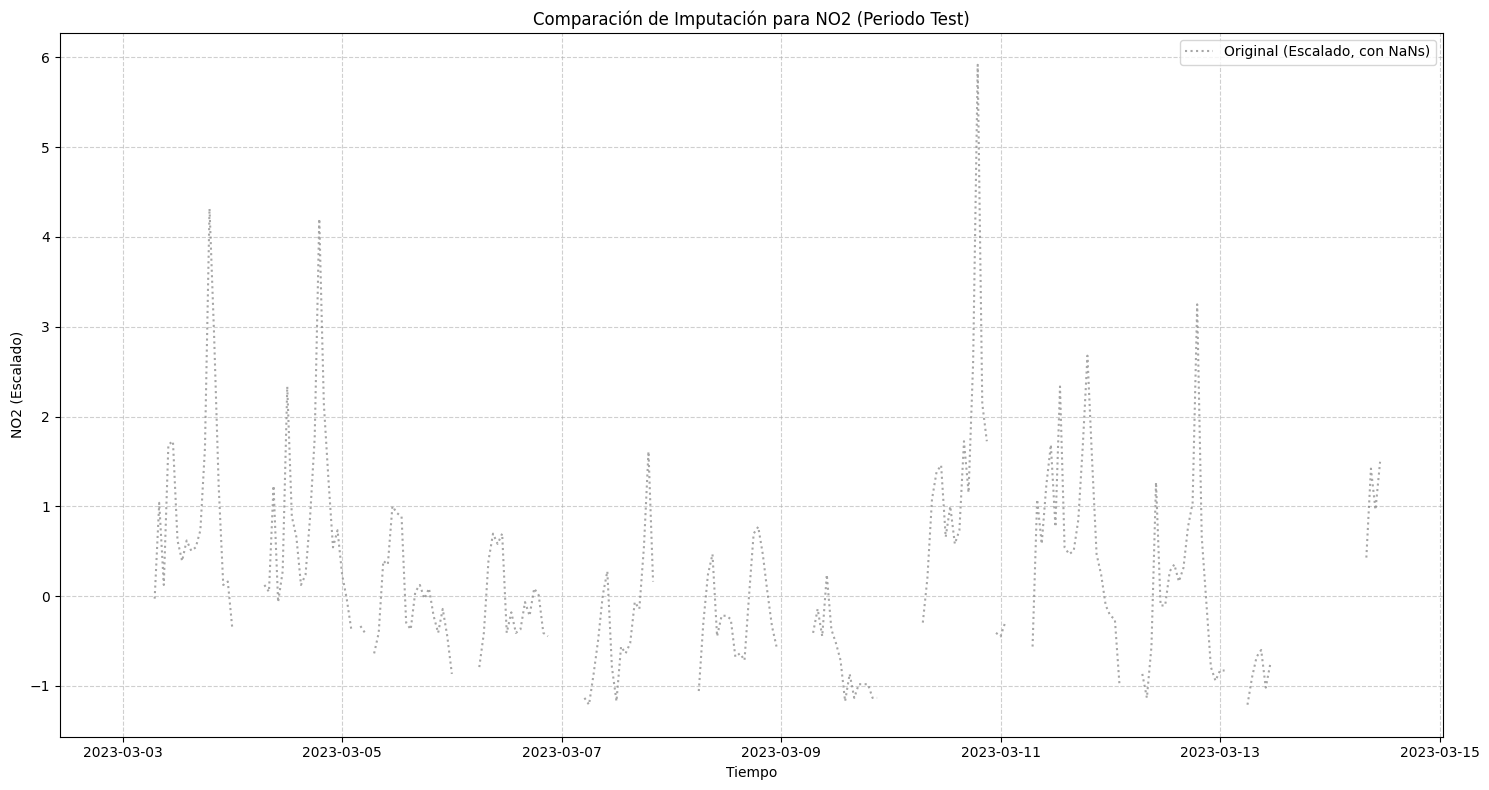

In [32]:
# ## 7. Visualizar Resultados (Ejemplo: NO2)

# Seleccionar una característica para visualizar
feature_to_plot = "NO2"
if feature_to_plot not in config.FEATURE_COLUMNS:
    print(f"Advertencia: '{feature_to_plot}' no está en las columnas de características. Saltando gráfico.")
else:
    feature_index = config.FEATURE_COLUMNS.index(feature_to_plot)

    # Obtener datos originales de test (antes de ventanear, potencialmente sin escalar para interpretabilidad)
    test_df_original = periodo_1_padded.loc[config.TEST_START_DATE:config.TEST_END_DATE]#[feature_to_plot]
    # Ajustar por fecha final exclusiva si es necesario basado en cómo se hizo el split
    # Ejemplo: si TEST_END_DATE = "2023-03-15", loc incluirá hasta "2023-03-14 23:00:00"
    # pero si los datos preprocesados excluyen el último día, ajustar aquí:
    # test_df_original = test_df_original.iloc[:-1] # O ajustar basado en el número exacto de filas


    # Reestructurar datos imputados a DataFrame para facilitar la visualización
    # Usar el scaler para invertir la transformación si se desea escala original
    scaler = processed_data['scaler']
    test_index_full = processed_data['test_index'] # Índice antes de ventanear

    plt.figure(figsize=(15, 8))
    plt.title(f"Comparación de Imputación para {feature_to_plot} (Periodo Test)")
    plt.xlabel("Tiempo")
    plt.ylabel(f"{feature_to_plot} (Escalado)") # Etiquetar como escalado

    # Graficar datos originales con valores faltantes (escalados)
    # Asegurarse que test_df_original tenga las columnas correctas antes de transformar
    original_scaled_test_data = scaler.transform(test_df_original[config.FEATURE_COLUMNS])
    original_series_scaled = pd.Series(original_scaled_test_data[:, feature_index], index=test_df_original.index)
    plt.plot(original_series_scaled.index, original_series_scaled.values, label='Original (Escalado, con NaNs)', color='gray', alpha=0.7, linestyle=':')

    # Graficar Ground Truth (donde se introdujo la ausencia) - escalado
    # Necesitamos reconstruir la serie temporal ground truth desde test_X_ori
    # Usar la utilidad de reestructuración
    ground_truth_df = utils.reshape_imputed_to_df(
         dataset_for_testing['X_ori'], # Datos escalados ANTES de enmascarar
         test_index_full, # Usar el índice antes de ventanear
         config.FEATURE_COLUMNS,
         config.N_STEPS
         )

    # Extraer el rango de tiempo relevante para graficar
    # Asegurarse que los índices coincidan con original_series_scaled
    plot_start = original_series_scaled.index.min()
    plot_end = original_series_scaled.index.max()

    # Verificar si las fechas están en ground_truth_df
    if plot_start in ground_truth_df.index and plot_end in ground_truth_df.index:
        ground_truth_series = ground_truth_df.loc[plot_start:plot_end, feature_to_plot]

        # Marcar los puntos que eran originalmente faltantes (usando la máscara)
        mask_flat = dataset_for_testing['indicating_mask'].reshape(-1, processed_data['n_features'])
        # Crear índice para la máscara aplanada que coincida con ground_truth_df
        mask_index = ground_truth_df.index[:len(mask_flat)] # Asegurar que no exceda la longitud
        mask_series = pd.Series(mask_flat[:, feature_index], index=mask_index).loc[plot_start:plot_end]

        missing_indices = mask_series[mask_series == 1].index

        plt.plot(ground_truth_series.index, ground_truth_series.values, label='Ground Truth (Escalado)', color='black', linewidth=1.5)
        # Asegurar que los missing_indices existen en ground_truth_series antes de graficar
        valid_missing_indices = missing_indices.intersection(ground_truth_series.index)
        plt.scatter(valid_missing_indices, ground_truth_series.loc[valid_missing_indices], color='red', s=15, label='Puntos Imputados (Verdad)', zorder=5)

    else:
        print("Advertencia: Rango de fechas de test original no encontrado completamente en datos ground truth reconstruidos. Saltando gráfico de ground truth.")
        ground_truth_series = None # Para evitar errores posteriores


    # Graficar resultados imputados
    plot_methods = ['median', 'linear', 'saits'] # Elegir métodos a graficar
    colors = ['blue', 'green', 'orange', 'purple', 'brown']
    linestyles = ['--', '-.', ':']

    for i, method in enumerate(plot_methods):
        if method in imputed_results:
            # Verificar si las columnas necesitan alineación (ej., ffill/bfill)
            current_cols = config.FEATURE_COLUMNS
            current_feature_index = feature_index
            y_pred = imputed_results[method]

            # Ajustar columnas y índice de característica si se eliminaron columnas para este método
            if method in ['ffill_bfill', 'bfill_ffill'] and cols_to_drop_indices:
                 current_cols = [col for idx, col in enumerate(config.FEATURE_COLUMNS) if idx not in cols_to_drop_indices]
                 if feature_to_plot in current_cols:
                     current_feature_index = current_cols.index(feature_to_plot)
                 else:
                     print(f"Saltando gráfico para {method} - {feature_to_plot} fue eliminada.")
                     continue # Saltar gráfico de este método para esta característica
                 # y_pred ya está ajustado

            # Reestructurar la predicción
            imputed_df = utils.reshape_imputed_to_df(
                 y_pred,
                 test_index_full, # Usar índice antes de ventanear
                 current_cols, # Usar columnas potencialmente reducidas
                 config.N_STEPS
            )

            # Extraer la serie y graficar en el rango correcto
            if plot_start in imputed_df.index and plot_end in imputed_df.index:
                imputed_series = imputed_df.loc[plot_start:plot_end, feature_to_plot]
                plt.plot(imputed_series.index, imputed_series.values,
                         label=f'{method.title()} Imputado',
                         color=colors[i % len(colors)],
                         linestyle=linestyles[i % len(linestyles)],
                         alpha=0.8)
            else:
                 print(f"Advertencia: Rango de fechas de test original no encontrado completamente en datos imputados ({method}). Saltando gráfico parcial.")


    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## 8. Opcional: Guardar Resultados

Podemos guardar la tabla de evaluación y/o los datos imputados (por ejemplo, los resultados de SAITS) en archivos CSV si es necesario para análisis posteriores o informes.

In [33]:
# Guardar la tabla de evaluación
# evaluation_table.to_csv(f"{config.RESULTS_DIR}/imputation_evaluation.csv")
# print(f"Resultados de evaluación guardados en {config.RESULTS_DIR}/imputation_evaluation.csv")

# Guardar datos imputados (ej. resultado de SAITS) si es necesario
# saits_imputed_df = utils.reshape_imputed_to_df(...) # Necesitas reconstruir el DataFrame
# saits_imputed_df.to_csv(...)

print("\nFlujo de trabajo finalizado.")


Flujo de trabajo finalizado.
